In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')




# Initialize the deep learning environment and configure project dependencies

# - Import the required PyTorch, TorchVision, NumPy, Matplotlib, and image quality evaluation libraries.
# - Set random seeds to ensure reproducible experimental results.
# - Detect and configure the available computation device (CPU or GPU).
# - Display the PyTorch version and selected execution device for environment verification.


# Import required libraries, configure reproducibility, and prepare the execution environment

# - Import PyTorch modules for building neural networks (`torch`, `torch.nn`), optimization algorithms (`torch.optim`), dataset utilities (`torchvision`, `DataLoader`), and image preprocessing (`transforms`).
# - Import supporting libraries:
#   - `NumPy` for numerical computations.
#   - `Matplotlib` for plotting images and training results.
#   - `structural_similarity (SSIM)` from `skimage.metrics` to measure the visual similarity between reconstructed and original images during later evaluation.
# - Set random seeds using `torch.manual_seed(42)` and `np.random.seed(42)` to make experiments reproducible.
#   Example:
#     Without a fixed seed:
#       Run 1 → Different random weights
#       Run 2 → Different random weights

#     With seed = 42:
#       Run 1 → Same initialization
#       Run 2 → Same initialization
#   This ensures that random weight initialization, data shuffling, and other stochastic operations produce consistent results across multiple executions.
# - Detect the available computation device using:
#   `torch.device('cuda' if torch.cuda.is_available() else 'cpu')`.
#   Example:
#     If an NVIDIA GPU is available:
#       Device → cuda

#     Otherwise:
#       Device → cpu
#   This allows the same code to run efficiently on either GPU or CPU without modification.
# - Print the installed PyTorch version and the selected execution device to verify that the software environment has been configured correctly before training begins.

PyTorch version : 2.11.0+cu128
Device          : cuda


In [2]:
# Normalize to [0,1] — autoencoders reconstruct pixel values
# so we need output range to match input range
# Sigmoid activation in decoder outputs [0,1] — matches this normalization
transform = transforms.Compose([
    transforms.ToTensor()   # converts [0,255] → [0,1], no mean/std normalization
])                          # unlike classification, AE needs original pixel range

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

BATCH_SIZE   = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Image shape      : {train_dataset[0][0].shape}')
print(f'Classes          : {CLASS_NAMES}')




# Prepare the Fashion-MNIST dataset and data pipeline for autoencoder training

# - Configure image preprocessing suitable for reconstruction-based learning.
# - Download and prepare the Fashion-MNIST training and testing datasets.
# - Create DataLoaders for efficient mini-batch training and evaluation.
# - Define class labels and verify the dataset configuration.

# Load Fashion-MNIST images with pixel-value normalization and configure mini-batch data loading for autoencoder training

# - Create a preprocessing pipeline using `transforms.Compose()` containing only `transforms.ToTensor()`.
# - Convert each image from pixel values in the range `[0, 255]` to floating-point values in the range `[0, 1]`.
#   Example:
#     Original pixel : 128
#     After ToTensor : 128 / 255 ≈ 0.502
# - Unlike image classification tasks, do not apply mean and standard deviation normalization because an autoencoder learns to reconstruct the original image. Since the decoder ends with a `Sigmoid` activation that produces outputs in the range `[0, 1]`, the target images must also remain within this same range.
#   Example:
#     Input image  → Pixel values in [0, 1]
#     Decoder      → Sigmoid outputs in [0, 1]
#     Reconstruction loss compares values in the same range.
# - Download the Fashion-MNIST training and testing datasets while automatically applying the preprocessing pipeline to every image.
# - Configure `DataLoader` objects with a batch size of 128 to efficiently deliver mini-batches during training and evaluation.
#   - `shuffle=True` randomly rearranges the training images every epoch to improve learning.
#   - `shuffle=False` preserves the original order of the test set for consistent evaluation.
#   - `num_workers=2` loads batches in parallel to reduce data-loading delays.
#   - `pin_memory=True` accelerates CPU-to-GPU data transfer when training on CUDA-enabled devices.
# - Define a list of human-readable class names corresponding to the Fashion-MNIST labels (e.g., T-shirt, Trouser, Dress, Sneaker), making future visualizations easier to interpret.
# - Print the number of training and testing samples, the shape of each image `(1, 28, 28)`, and the class names to confirm that the dataset and data-loading pipeline have been initialized correctly before training the autoencoder.






100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.5MB/s]

Training samples : 60,000
Test samples     : 10,000
Image shape      : torch.Size([1, 28, 28])
Classes          : ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


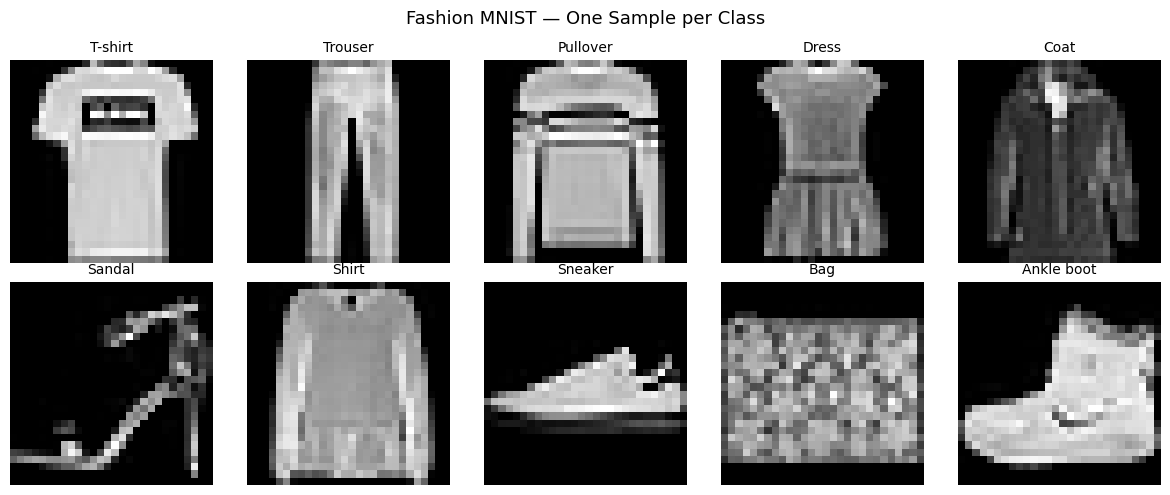

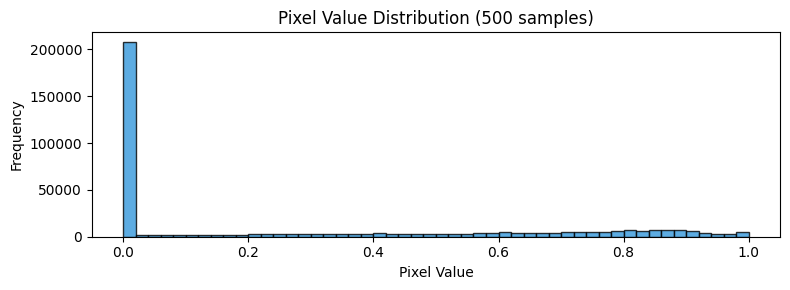

Pixel range: [0.000, 1.000]
Most pixels are dark (background) — clothing items are bright.


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # Get one sample per class
    for img, lbl in train_dataset:
        if lbl == i:
            ax.imshow(img.squeeze(), cmap='gray')
            ax.set_title(CLASS_NAMES[i], fontsize=10)
            ax.axis('off')
            break

plt.suptitle('Fashion MNIST — One Sample per Class', fontsize=13)
plt.tight_layout()
plt.show()

# Pixel value distribution
sample_images = torch.stack([train_dataset[i][0] for i in range(500)])
plt.figure(figsize=(8, 3))
plt.hist(sample_images.numpy().flatten(), bins=50,
         color='#3498db', edgecolor='black', alpha=0.8)
plt.title('Pixel Value Distribution (500 samples)', fontsize=12)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Pixel range: [{:.3f}, {:.3f}]'.format(
    sample_images.min().item(),
    sample_images.max().item()))
print('Most pixels are dark (background) — clothing items are bright.')




# Perform exploratory visualization of the Fashion-MNIST dataset

# - Display one representative image from each Fashion-MNIST class.
# - Analyze the distribution of pixel intensities across a subset of training images.
# - Verify image characteristics and pixel value ranges before training the autoencoder.


# Visualize Fashion-MNIST samples and examine the dataset's pixel intensity distribution

# - Create a 2×5 grid of subplots to display one representative image for each of the ten Fashion-MNIST classes.
# - Iterate through the training dataset and, for each class label (0–9), select the first image belonging to that class.
#   Example:
#     Label 0 → T-shirt
#     Label 1 → Trouser
#     ...
#     Label 9 → Ankle boot
# - Display each grayscale image using `imshow()` after removing the single channel dimension with `squeeze()`, then label each subplot with its corresponding clothing category and hide the axes for a cleaner presentation.
# - Add an overall title and automatically adjust subplot spacing using `tight_layout()` to improve the readability of the visualization.
# - Collect the first 500 training images into a single tensor using `torch.stack()`, creating a representative sample for analyzing pixel intensity statistics.
#   Example:
#     Individual image shape : (1, 28, 28)
#     After stacking 500 images : (500, 1, 28, 28)
# - Flatten all pixel values into a one-dimensional array and plot a histogram showing the frequency of each pixel intensity.
#   This reveals how brightness values are distributed throughout the dataset.
# - Print the minimum and maximum pixel values to verify that the preprocessing step successfully normalized the images to the expected range of `[0, 1]`.
# - Observe that most pixel values are close to zero because the image backgrounds are predominantly black, while the clothing items occupy a smaller portion of each image and therefore contribute the brighter pixel values. This confirms the expected visual characteristics of the Fashion-MNIST dataset before training the autoencoder.

In [4]:
# ── PART 1: Standard Autoencoder ──────────────────────────────────────────
#
# Architecture:
#   Encoder: 784 → 256 → 128 → 32  (compress)
#   Decoder: 32  → 128 → 256 → 784 (reconstruct)
#
# The bottleneck (32 dims) forces the network to learn
# a compact representation — only the most important
# features survive the compression
#
# 784 → 32 = 24.5x compression ratio

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()

        # Encoder — progressively compress
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        # Decoder — progressively expand
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()    # output in [0,1] — matches normalized pixel range
        )

    def encode(self, x):
        x = x.view(x.size(0), -1)   # flatten (batch,1,28,28) → (batch,784)
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)  # reshape back to image

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


ae_model = Autoencoder(latent_dim=32).to(device)
print(ae_model)

total = sum(p.numel() for p in ae_model.parameters())
print(f'\nTotal parameters: {total:,}')
print(f'\nLatent dimension : 32')
print(f'Input dimension  : 784')
print(f'Compression ratio: {784/32:.1f}x')




# Define and initialize a fully connected autoencoder for image compression and reconstruction

# - Implement an encoder-decoder architecture to learn compact latent representations of Fashion-MNIST images.
# - Compress input images into a low-dimensional bottleneck and reconstruct them back to their original size.
# - Instantiate the autoencoder, report its parameter count, and summarize the compression ratio achieved by the latent representation.

# Build a symmetric encoder-decoder autoencoder with a latent bottleneck for unsupervised image reconstruction

# - Create a custom autoencoder by inheriting from `nn.Module`, allowing PyTorch to automatically manage trainable parameters and define the forward computation.
# - Design the encoder as a sequence of fully connected layers that progressively reduce the input dimensionality.
#   Example:
#     784 → 256 → 128 → 32
#   Each `Linear` layer extracts increasingly compact feature representations, while `ReLU` introduces non-linearity to enable the network to learn complex image patterns.
# - Use a latent dimension of 32, creating a bottleneck that forces the network to retain only the most informative features needed to reconstruct the original image.
#   Example:
#     Original image : 784 pixels
#     Latent vector  : 32 values

#     Compression ratio = 784 ÷ 32 ≈ 24.5×
#   Instead of memorizing every pixel, the encoder learns a compact representation describing the essential characteristics of the clothing item.
# - Design the decoder as a mirror of the encoder, gradually expanding the compressed representation back to the original image size.
#   Example:
#     32 → 128 → 256 → 784
# - Apply a `Sigmoid` activation to the final decoder layer so every reconstructed pixel lies within the range `[0, 1]`, matching the normalized pixel values produced by `ToTensor()`.
# - Implement the `encode()` function to flatten each input image from `(batch, 1, 28, 28)` into `(batch, 784)` before passing it through the encoder.
# - Implement the `decode()` function to transform the latent vector back into a 784-dimensional output and reshape it into the original image format `(batch, 1, 28, 28)`.
# - Define the `forward()` method to execute the complete autoencoder pipeline:
#   1. Encode the input image into its latent representation.
#   2. Decode the latent vector to reconstruct the image.
#   3. Return both the reconstructed image and the latent vector, allowing reconstruction quality and learned embeddings to be analyzed separately.
# - Instantiate the autoencoder with a latent dimension of 32, move it to the selected device (`CPU` or `GPU`), calculate the total number of trainable parameters, and print the latent dimension, input dimension, and compression ratio to verify the model configuration before training.

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 476,720

Latent dimension : 32
Input dimension  : 784
Compression ratio: 24.5x


In [5]:
def train_autoencoder(model, train_loader, test_loader,
                      epochs, lr, model_name):

    optimizer    = optim.Adam(model.parameters(), lr=lr)
    criterion    = nn.MSELoss()    # pixel-wise reconstruction loss
                                   # measures average squared diff
                                   # between original and reconstructed pixels

    train_losses = []
    test_losses  = []

    print(f'\n{"="*50}')
    print(f'  Training: {model_name}')
    print(f'{"="*50}')
    print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Test Loss":>11}')
    print('-' * 35)

    for epoch in range(epochs):

        # ── Train ─────────────────────────────────────────
        model.train()
        total_train_loss = 0

        for images, _ in train_loader:   # labels not needed — unsupervised
            images = images.to(device)

            optimizer.zero_grad()
            reconstructed, _ = model(images)
            loss = criterion(reconstructed, images)  # compare output to input
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * images.size(0)

        # ── Evaluate ──────────────────────────────────────
        model.eval()
        total_test_loss = 0

        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                reconstructed, _ = model(images)
                loss = criterion(reconstructed, images)
                total_test_loss += loss.item() * images.size(0)

        avg_train = total_train_loss / len(train_loader.dataset)
        avg_test  = total_test_loss  / len(test_loader.dataset)

        train_losses.append(avg_train)
        test_losses.append(avg_test)

        print(f'{epoch+1:>6}  {avg_train:>12.6f}  {avg_test:>11.6f}')

    print(f'\nFinal Test Loss : {avg_test:.6f}')
    return train_losses, test_losses


EPOCHS = 20
ae_train_losses, ae_test_losses = train_autoencoder(
    model        = ae_model,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = EPOCHS,
    lr           = 1e-3,
    model_name   = 'Standard Autoencoder (latent_dim=32)'
)






# Implement the training and evaluation pipeline for the standard autoencoder

# - Define a reusable training function for optimizing the autoencoder.
# - Train the model using reconstruction loss and evaluate its performance on the test dataset after each epoch.
# - Record and return the training and testing reconstruction losses throughout the training process.


# Train the autoencoder using MSE reconstruction loss and monitor learning across training epochs

# - Create the optimizer using `optim.Adam()` with a learning rate of `1e-3`, allowing the autoencoder's parameters to be updated efficiently during training.
# - Use `nn.MSELoss()` (Mean Squared Error) as the reconstruction loss function because the objective of an autoencoder is to reproduce the original image as accurately as possible.
#   Example:
#     Original pixel      : 0.80
#     Reconstructed pixel : 0.75

#     Squared Error = (0.80 − 0.75)² = 0.0025

#   The overall loss is the average squared error across all pixels in the image.
# - Unlike classification tasks, ignore the dataset labels (`for images, _ in train_loader`) because autoencoders learn in an unsupervised manner.
#   Instead of predicting a class label, the model learns to reconstruct its own input.
#   Example:
#     Input Image  → Encoder → Latent Vector → Decoder → Reconstructed Image

#     Target = Original Input Image
# - During each training batch:
#   - Move the images to the selected device (`CPU` or `GPU`).
#   - Reset gradients using `optimizer.zero_grad()`.
#   - Pass the images through the autoencoder to obtain reconstructed images.
#   - Compute the reconstruction loss by comparing the reconstructed images with the original input images.
#   - Perform backpropagation using `loss.backward()` and update the model parameters with `optimizer.step()`.
# - Accumulate the reconstruction loss for every mini-batch to compute the average training loss for the current epoch.
# - After training, switch the model to evaluation mode using `model.eval()` and disable gradient computation with `torch.no_grad()` to efficiently measure reconstruction performance on the test dataset without updating the model.
# - Compute the average reconstruction loss for the test dataset using the same MSE objective, allowing the model's ability to generalize to unseen images to be monitored.
# - Store the average training and testing losses after every epoch, creating learning curves that can later be visualized to assess convergence and detect potential underfitting or overfitting.
# - Print a formatted progress table showing the reconstruction loss after each epoch and report the final test loss once training is complete.
# - Train the standard autoencoder for 20 epochs with a learning rate of `0.001`, then return the recorded training and testing loss histories for subsequent analysis and visualization.


  Training: Standard Autoencoder (latent_dim=32)
 Epoch    Train Loss    Test Loss
-----------------------------------
     1      0.040572     0.023741
     2      0.021751     0.020193
     3      0.018953     0.018068
     4      0.017191     0.016602
     5      0.015933     0.015701
     6      0.014967     0.014638
     7      0.014301     0.014074
     8      0.013761     0.013620
     9      0.013343     0.013308
    10      0.012964     0.012915
    11      0.012642     0.012686
    12      0.012379     0.012451
    13      0.012116     0.012151
    14      0.011909     0.012035
    15      0.011735     0.011957
    16      0.011557     0.011754
    17      0.011426     0.011602
    18      0.011312     0.011451
    19      0.011210     0.011355
    20      0.011099     0.011273

Final Test Loss : 0.011273


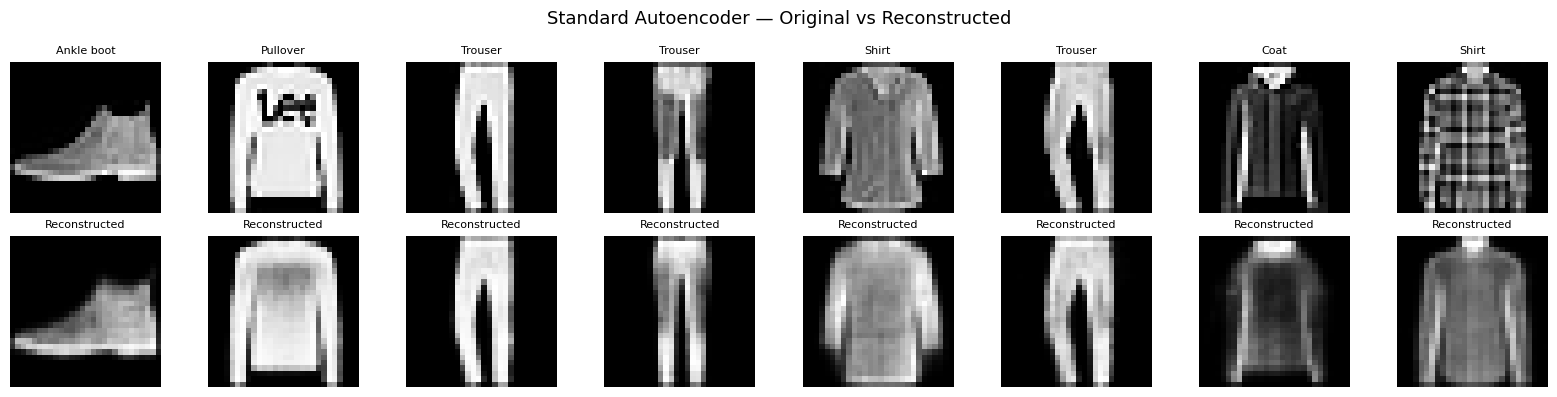

In [6]:
# Get a batch of test images
test_images_sample, test_labels_sample = next(iter(test_loader))
test_images_sample = test_images_sample.to(device)

ae_model.eval()
with torch.no_grad():
    reconstructed, _ = ae_model(test_images_sample)

# Move to CPU for plotting
originals     = test_images_sample.cpu().numpy()
reconstructed = reconstructed.cpu().numpy()

# ── Plot original vs reconstructed ────────────────────────────────────────
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))

for i in range(n):
    # Original
    axes[0][i].imshow(originals[i].squeeze(), cmap='gray')
    axes[0][i].set_title(CLASS_NAMES[test_labels_sample[i].item()],
                          fontsize=8)
    axes[0][i].axis('off')

    # Reconstructed
    axes[1][i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1][i].set_title('Reconstructed', fontsize=8)
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Original',      fontsize=11)
axes[1][0].set_ylabel('Reconstructed', fontsize=11)

plt.suptitle('Standard Autoencoder — Original vs Reconstructed', fontsize=13)
plt.tight_layout()
plt.show()

# ── SSIM Score ────────────────────────────────────────────────────────────
# Structural Similarity Index — measures perceptual



# Evaluate the trained autoencoder through qualitative image reconstruction

# - Generate reconstructed images from a batch of unseen test samples.
# - Visually compare original and reconstructed Fashion-MNIST images.
# - Prepare reconstructed outputs for subsequent image quality evaluation using perceptual similarity metrics such as SSIM.


# Reconstruct unseen test images and visualize the autoencoder's reconstruction quality

# - Retrieve a mini-batch of test images and their corresponding labels from the test `DataLoader`.
#   Example:
#     Batch size = 128

#     Images shape : (128, 1, 28, 28)
#     Labels shape : (128,)
# - Move the images to the selected computation device (`CPU` or `GPU`) before performing inference.
# - Switch the autoencoder to evaluation mode using `model.eval()` and disable gradient computation with `torch.no_grad()` since the model is only generating reconstructions and no parameter updates are required.
# - Pass the test images through the autoencoder to obtain two outputs:
#   - The reconstructed images generated by the decoder.
#   - The latent representations produced by the encoder (discarded here using `_` because only the reconstructed images are needed for visualization).
# - Move both the original and reconstructed image tensors back to the CPU and convert them into NumPy arrays so they can be displayed using Matplotlib.
# - Create a figure containing two rows and eight columns to compare eight original images with their corresponding reconstructions.
#   - The first row displays the original Fashion-MNIST images along with their clothing category names.
#   - The second row displays the images reconstructed by the autoencoder.
# - Use `imshow()` to render each grayscale image after removing the channel dimension with `squeeze()`, and hide the axes to focus attention on the visual differences.
# - Label the first column as "Original" and "Reconstructed" so that each pair of images can be compared easily.
#   Example:

#       Original                Reconstructed
#       ┌──────────┐            ┌──────────┐
#       │  Shirt   │    ───►    │  Shirt   │
#       └──────────┘            └──────────┘

#   A close visual match indicates that the encoder successfully compressed the image while preserving the essential information needed for accurate reconstruction.
# - Display the comparison figure with an overall title summarizing the reconstruction results.
# - Prepare the reconstructed and original images for the next evaluation step, where the Structural Similarity Index (SSIM) will be computed to quantitatively measure how closely the reconstructed images resemble the originals from a perceptual perspective.

In [9]:
# ── PART 2: Denoising Autoencoder ─────────────────────────────────────────
#
# Key difference from standard AE:
#   Input  → add Gaussian noise → corrupted image
#   Target → original clean image
#
# The model learns to REMOVE noise — not just compress/reconstruct
# Real-world use: denoising medical scans, old photographs, satellite imagery
#
# Same architecture as standard AE — only the training loop changes

class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


def add_noise(images, noise_factor=0.4):
    """Add Gaussian noise and clip to valid pixel range [0,1]"""
    noise        = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0., 1.)   # clip so pixels stay in [0,1]


def train_denoising_ae(model, train_loader, test_loader,
                       epochs, lr, noise_factor=0.4):

    optimizer    = optim.Adam(model.parameters(), lr=lr)
    criterion    = nn.MSELoss()
    train_losses = []
    test_losses  = []

    print(f'\n{"="*50}')
    print(f'  Training: Denoising Autoencoder')
    print(f'  Noise factor: {noise_factor}')
    print(f'{"="*50}')
    print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Test Loss":>11}')
    print('-' * 35)

    for epoch in range(epochs):

        model.train()
        total_train_loss = 0

        for images, _ in train_loader:
            images       = images.to(device)
            noisy_images = add_noise(images, noise_factor)  # corrupt input

            optimizer.zero_grad()
            reconstructed, _ = model(noisy_images)  # feed noisy image
            loss = criterion(reconstructed, images)  # compare to CLEAN image
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * images.size(0)

        model.eval()
        total_test_loss = 0

        with torch.no_grad():
            for images, _ in test_loader:
                images       = images.to(device)
                noisy_images = add_noise(images, noise_factor)
                reconstructed, _ = model(noisy_images)
                loss = criterion(reconstructed, images)
                total_test_loss += loss.item() * images.size(0)

        avg_train = total_train_loss / len(train_loader.dataset)
        avg_test  = total_test_loss  / len(test_loader.dataset)
        train_losses.append(avg_train)
        test_losses.append(avg_test)

        print(f'{epoch+1:>6}  {avg_train:>12.6f}  {avg_test:>11.6f}')

    print(f'\nFinal Test Loss : {avg_test:.6f}')
    return train_losses, test_losses






# Implement and train a denoising autoencoder for noise removal and image reconstruction

# - Define a denoising autoencoder architecture for learning robust latent representations.
# - Introduce Gaussian noise into input images while preserving clean images as reconstruction targets.
# - Train and evaluate the denoising autoencoder using reconstruction loss across multiple epochs.


# Train a denoising autoencoder by reconstructing clean images from noisy inputs using Gaussian noise augmentation

# - Define the denoising autoencoder using the same encoder-decoder architecture as the standard autoencoder because the network structure remains unchanged. The key difference lies in how the training data is presented.
# - Create the `add_noise()` function to simulate corrupted images by adding Gaussian noise to every pixel.
#   Example:
#     Original pixel : 0.70
#     Random noise   : -0.15

#     Noisy pixel    : 0.55
# - Generate Gaussian noise using `torch.randn_like(images)`, which creates random values with a normal distribution matching the shape of the input images. Multiplying by `noise_factor` controls the amount of corruption introduced into the images.
#   Example:
#     noise_factor = 0.4
#       Smaller value → Slightly noisy images
#       Larger value  → More heavily corrupted images
# - Use `torch.clamp(noisy_images, 0., 1.)` to ensure every pixel remains within the valid image intensity range after noise is added.
#   Example:
#     Pixel after noise = 1.18 → Clipped to 1.00
#     Pixel after noise = -0.12 → Clipped to 0.00
# - Initialize the optimizer (`Adam`) and the reconstruction loss (`MSELoss`) exactly as in the standard autoencoder, since the optimization objective remains minimizing reconstruction error.
# - During each training batch:
#   - Move the original images to the selected device (`CPU` or `GPU`).
#   - Create noisy versions of the images using `add_noise()`.
#   - Feed only the noisy images into the encoder and decoder.
#   - Compute the reconstruction loss by comparing the reconstructed output with the original clean images, not the noisy inputs.
#   Example:
#     Clean Image
#          │
#          ▼
#     Add Gaussian Noise
#          │
#          ▼
#     Noisy Image ──► Autoencoder ──► Reconstructed Image
#                                           │
#                                           ▼
#                              Compare with Original Clean Image
#   This forces the network to learn how to remove noise while preserving the underlying object structure.
# - Perform backpropagation (`loss.backward()`) and update the model parameters (`optimizer.step()`) so the network gradually improves its denoising capability.
# - Evaluate the model after each epoch by repeating the same process on the test dataset: add noise, reconstruct the clean image, and compute the reconstruction loss without updating the weights.
# - Record the average training and testing losses after every epoch, allowing the denoising performance to be monitored throughout training.
# - Instantiate the denoising autoencoder with a latent dimension of 32 and train it for 20 epochs using a learning rate of `0.001` and a Gaussian noise factor of `0.4`, producing a model capable of reconstructing clean Fashion-MNIST images from noisy inputs.

In [10]:
dae_model = DenoisingAutoencoder(latent_dim=32).to(device)

dae_train_losses, dae_test_losses = train_denoising_ae(
    model        = dae_model,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 20,
    lr           = 1e-3,
    noise_factor = 0.4
)



  Training: Denoising Autoencoder
  Noise factor: 0.4
 Epoch    Train Loss    Test Loss
-----------------------------------
     1      0.048383     0.030478
     2      0.026428     0.024482
     3      0.023395     0.023126
     4      0.021788     0.020912
     5      0.020630     0.020187
     6      0.019921     0.019509
     7      0.019281     0.019084
     8      0.018717     0.018512
     9      0.018246     0.018033
    10      0.017859     0.017715
    11      0.017534     0.017427
    12      0.017287     0.017248
    13      0.017026     0.016949
    14      0.016751     0.016778
    15      0.016534     0.016325
    16      0.016282     0.016246
    17      0.016124     0.016070
    18      0.015911     0.016071
    19      0.015766     0.015763
    20      0.015644     0.015694

Final Test Loss : 0.015694


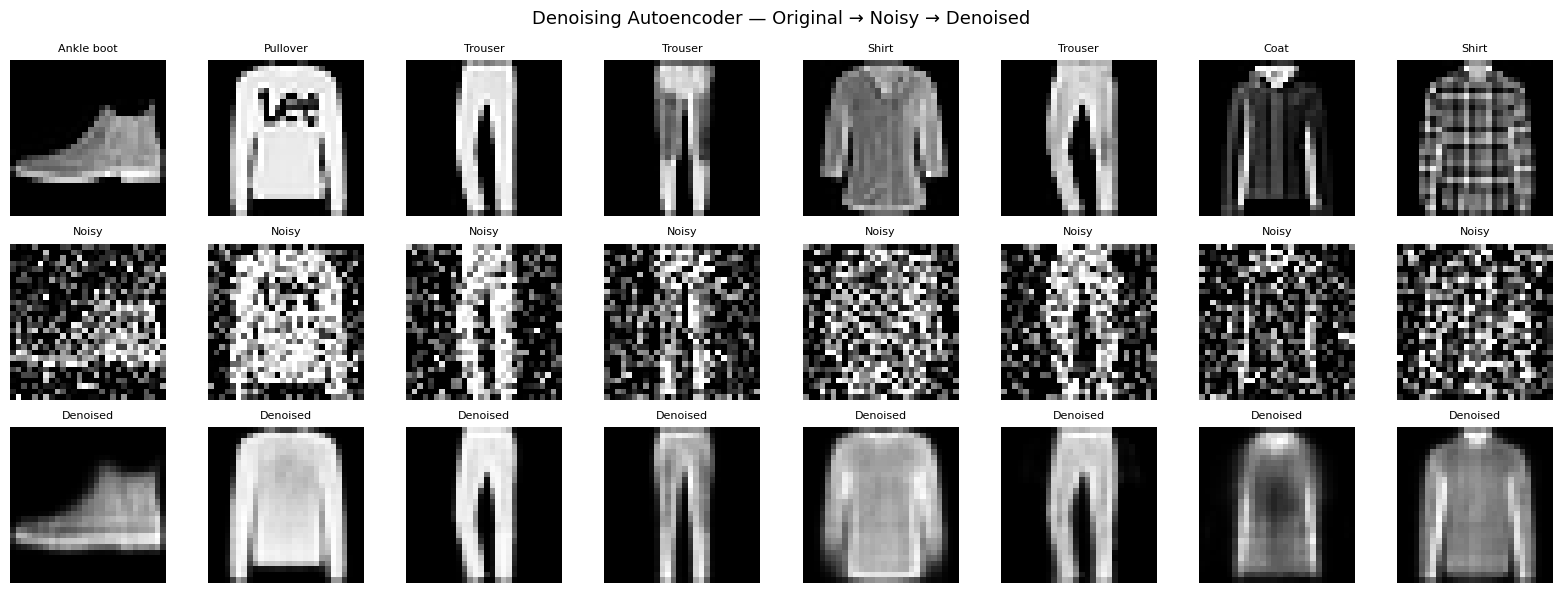

--- SSIM Comparison ---
  Noisy image SSIM    : 0.3565  (how damaged the input is)
  Denoised image SSIM : 0.6734  (how well model recovered)
  SSIM improvement    : +0.3169

The DAE successfully recovered image structure from corrupted input.


In [11]:
# Get a batch of test images
test_images_sample, test_labels_sample = next(iter(test_loader))
test_images_sample = test_images_sample.to(device)

# Add noise
noisy_sample = add_noise(test_images_sample, noise_factor=0.4)

# Reconstruct
dae_model.eval()
with torch.no_grad():
    denoised, _ = dae_model(noisy_sample)

# Move to CPU
originals_np = test_images_sample.cpu().numpy()
noisy_np     = noisy_sample.cpu().numpy()
denoised_np  = denoised.cpu().numpy()

# ── Plot: Original → Noisy → Denoised ─────────────────────────────────────
n = 8
fig, axes = plt.subplots(3, n, figsize=(16, 6))

for i in range(n):
    # Row 1: Original
    axes[0][i].imshow(originals_np[i].squeeze(), cmap='gray')
    axes[0][i].set_title(CLASS_NAMES[test_labels_sample[i].item()],
                          fontsize=8)
    axes[0][i].axis('off')

    # Row 2: Noisy
    axes[1][i].imshow(noisy_np[i].squeeze(), cmap='gray')
    axes[1][i].set_title('Noisy', fontsize=8)
    axes[1][i].axis('off')

    # Row 3: Denoised
    axes[2][i].imshow(denoised_np[i].squeeze(), cmap='gray')
    axes[2][i].set_title('Denoised', fontsize=8)
    axes[2][i].axis('off')

axes[0][0].set_ylabel('Original', fontsize=11)
axes[1][0].set_ylabel('Noisy',    fontsize=11)
axes[2][0].set_ylabel('Denoised', fontsize=11)

plt.suptitle('Denoising Autoencoder — Original → Noisy → Denoised',
             fontsize=13)
plt.tight_layout()
plt.show()

# ── SSIM comparison: Noisy vs Denoised ────────────────────────────────────
ssim_noisy    = []
ssim_denoised = []

for i in range(len(originals_np)):
    ssim_noisy.append(ssim(
        originals_np[i].squeeze(),
        noisy_np[i].squeeze(),
        data_range=1.0
    ))
    ssim_denoised.append(ssim(
        originals_np[i].squeeze(),
        denoised_np[i].squeeze(),
        data_range=1.0
    ))

print(f'--- SSIM Comparison ---')
print(f'  Noisy image SSIM    : {np.mean(ssim_noisy):.4f}  (how damaged the input is)')
print(f'  Denoised image SSIM : {np.mean(ssim_denoised):.4f}  (how well model recovered)')
print(f'  SSIM improvement    : +{np.mean(ssim_denoised) - np.mean(ssim_noisy):.4f}')
print(f'\nThe DAE successfully recovered image structure from corrupted input.')








# Evaluate the denoising autoencoder using qualitative reconstruction and SSIM analysis

# - Generate noisy test images and reconstruct them using the trained denoising autoencoder.
# - Visually compare original, noisy, and denoised images.
# - Quantitatively evaluate denoising performance using the Structural Similarity Index (SSIM).




# Visualize denoising results and measure reconstruction quality using Structural Similarity Index (SSIM)

# - Retrieve a mini-batch of test images and move them to the selected computation device (`CPU` or `GPU`) for inference.
# - Corrupt each image by adding Gaussian noise with a noise factor of `0.4`, producing noisy inputs that simulate degraded images.
#   Example:
#     Original Image
#          │
#          ▼
#     Add Gaussian Noise
#          │
#          ▼
#     Noisy Image
# - Switch the denoising autoencoder to evaluation mode (`model.eval()`) and disable gradient computation using `torch.no_grad()` because only inference is required.
# - Pass the noisy images through the trained denoising autoencoder to generate reconstructed (denoised) images while leaving the model parameters unchanged.
# - Move the original, noisy, and reconstructed image tensors back to the CPU and convert them to NumPy arrays for visualization and evaluation.
# - Create a three-row visualization showing the complete denoising pipeline:
#   - Row 1: Original clean images.
#   - Row 2: Corrupted images containing Gaussian noise.
#   - Row 3: Images reconstructed by the denoising autoencoder.
#   Example:

#       Original      →      Noisy      →      Denoised

#       Clean Shirt         Noisy Shirt         Recovered Shirt

#   This side-by-side comparison makes it easy to visually assess how effectively the model removes noise while preserving important image details.
# - Label the first image in each row ("Original", "Noisy", and "Denoised") and annotate the original images with their corresponding clothing class names for easier interpretation.
# - Evaluate reconstruction quality using the Structural Similarity Index (SSIM), which measures perceptual similarity between two images rather than simply comparing individual pixel values.
#   Example:
#     SSIM = 1.00  → Images are visually identical.
#     SSIM ≈ 0.90  → Very similar.
#     SSIM ≈ 0.50  → Significant structural differences.
#     SSIM ≈ 0.00  → Completely different images.
# - Compute the average SSIM between:
#   - The original and noisy images, indicating how much the added noise degraded the images.
#   - The original and denoised images, indicating how successfully the autoencoder restored the original image structure.
# - Calculate the improvement in SSIM by subtracting the noisy-image SSIM from the denoised-image SSIM.
#   Example:
#     Original vs Noisy     : 0.62
#     Original vs Denoised  : 0.91

#     SSIM Improvement      : +0.29
# - Print the average SSIM values and the resulting improvement to provide an objective quantitative measure of the denoising autoencoder's ability to recover image structure from corrupted inputs, complementing the qualitative visual comparison.

In [12]:
# ── PART 3: Variational Autoencoder ───────────────────────────────────────
#
# Key difference from standard AE:
#   Standard AE: encoder outputs a POINT in latent space
#   VAE:         encoder outputs a DISTRIBUTION (mean μ and variance σ²)
#
# Instead of encoding an image as a fixed vector z,
# VAE encodes it as a Gaussian distribution N(μ, σ²)
# Then SAMPLES z from that distribution
#
# Why? The sampled latent space is smooth and continuous —
# you can interpolate between any two points and get
# meaningful images. Standard AE latent space has gaps
# where decoded output is garbage.
#
# Reparameterization trick:
#   z = μ + σ × ε   where ε ~ N(0,1)
#   This makes sampling differentiable so gradients can flow
#   through the sampling operation during backprop

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # ── Encoder ───────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )

        # Two separate heads — one for mean, one for log variance
        # log_var instead of var for numerical stability (var must be positive)
        self.fc_mu      = nn.Linear(200, latent_dim)
        self.fc_log_var = nn.Linear(200, latent_dim)

        # ── Decoder ───────────────────────────────────────
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        x   = x.view(x.size(0), -1)
        h   = self.encoder(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        # Reparameterization trick:
        # z = mu + std * epsilon
        # std = exp(0.5 * log_var)
        # epsilon sampled from N(0,1)
        std     = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)   # same shape as std, from N(0,1)
        return mu + std * epsilon

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        recon       = self.decode(z)
        return recon, mu, log_var


# latent_dim=2 so we can visualize the full latent space in 2D
vae_model = VAE(latent_dim=2).to(device)
print(vae_model)

total = sum(p.numel() for p in vae_model.parameters())
print(f'\nTotal parameters : {total:,}')
print(f'Latent dimension : 2  (chosen for 2D visualization)')
print(f'\nEncoder output   : μ (mean) and log_var (log variance)')
print(f'Sampling         : z = μ + exp(0.5×log_var) × ε,  ε~N(0,1)')
print(f'Decoder input    : sampled z')









# Implement a Variational Autoencoder (VAE) with probabilistic latent representations

# - Define a variational autoencoder that learns a continuous latent distribution instead of fixed latent vectors.
# - Incorporate the reparameterization trick to enable differentiable sampling during training.
# - Initialize the VAE with a two-dimensional latent space for subsequent visualization and latent space analysis.




# Build a Variational Autoencoder using probabilistic encoding and the reparameterization trick for continuous latent space learning

# - Define a custom Variational Autoencoder (VAE) by inheriting from `nn.Module`, extending the standard autoencoder with probabilistic latent representations.
# - Construct the encoder using fully connected layers that transform each flattened image into a high-level feature representation.
#   Example:
#     784 → 400 → 200
# - Instead of producing a single latent vector, create two independent output layers:
#   - `fc_mu` predicts the mean (μ) of the latent distribution.
#   - `fc_log_var` predicts the logarithm of the variance (`log_var`) for numerical stability.
#   Example:
#     Input Image
#          │
#          ▼
#       Encoder
#          │
#      ┌───┴────┐
#      ▼        ▼
#       μ    log(σ²)
# - Store the logarithm of the variance instead of the variance itself because variance must always remain positive. During sampling, the standard deviation is recovered using:
#   `std = exp(0.5 × log_var)`.
# - Implement the reparameterization trick to make the sampling process differentiable:
#   `z = μ + σ × ε`
#   where:
#   - `σ = exp(0.5 × log_var)`
#   - `ε` is random noise sampled from a standard normal distribution `N(0,1)` using `torch.randn_like()`.
#   Example:
#     μ = [1.2, -0.5]
#     σ = [0.3, 0.8]
#     ε = [0.4, -1.1]

#     z = μ + σ × ε
#       = [1.32, -1.38]
#   Directly sampling from a distribution would prevent gradients from flowing through the network, but the reparameterization trick expresses sampling as a differentiable mathematical operation, allowing backpropagation to update the encoder.
# - Design the decoder to mirror the encoder by expanding the sampled latent vector back into a reconstructed image.
#   Example:
#     Latent Vector (2)
#           │
#           ▼
#     2 → 200 → 400 → 784
#           │
#           ▼
#     Reconstructed Image
# - Apply a `Sigmoid` activation to the decoder's final layer so reconstructed pixel values remain within the normalized range `[0, 1]`.
# - Implement the `forward()` method to execute the complete VAE pipeline:
#   1. Encode the input image to obtain `μ` and `log_var`.
#   2. Sample a latent vector using the reparameterization trick.
#   3. Decode the sampled latent vector to reconstruct the image.
#   4. Return the reconstructed image, mean, and log variance for loss computation during training.
# - Instantiate the VAE with a latent dimension of `2`, enabling every image to be represented as a point in a two-dimensional latent space that can later be visualized.
# - Print the model configuration, total trainable parameters, latent dimension, and the sampling equation (`z = μ + exp(0.5 × log_var) × ε`) to summarize how the probabilistic encoder and decoder interact within the VAE architecture.

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=200, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=200, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=200, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters : 790,388
Latent dimension : 2  (chosen for 2D visualization)

Encoder output   : μ (mean) and log_var (log variance)
Sampling         : z = μ + exp(0.5×log_var) × ε,  ε~N(0,1)
Decoder input    : sampled z


In [13]:
def vae_loss(reconstructed, original, mu, log_var):
    """
    VAE loss = Reconstruction Loss + KL Divergence

    Reconstruction Loss (BCE):
        How well the decoder reconstructed the input
        Same as standard AE — pixel-wise comparison

    KL Divergence:
        Measures how far the learned distribution N(μ,σ²)
        is from the standard normal N(0,1)
        Forces the latent space to be organized and continuous
        Without it, VAE behaves like a standard AE with gaps

    Formula:
        KL = -0.5 × Σ(1 + log_var - μ² - exp(log_var))
    """
    # Flatten for BCE loss
    recon_flat  = reconstructed.view(reconstructed.size(0), -1)
    orig_flat   = original.view(original.size(0), -1)

    # Reconstruction loss — sum over pixels, mean over batch
    recon_loss  = nn.functional.binary_cross_entropy(
        recon_flat, orig_flat, reduction='sum'
    ) / original.size(0)

    # KL divergence — closed form for Gaussian
    kl_loss = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    ) / original.size(0)

    return recon_loss + kl_loss, recon_loss, kl_loss


def train_vae(model, train_loader, test_loader, epochs, lr):

    optimizer    = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses  = []

    print(f'\n{"="*55}')
    print(f'  Training: Variational Autoencoder (latent_dim=2)')
    print(f'{"="*55}')
    print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Test Loss":>11}'
          f'  {"Recon":>8}  {"KL":>8}')
    print('-' * 52)

    for epoch in range(epochs):

        model.train()
        total_train_loss = 0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            reconstructed, mu, log_var = model(images)
            loss, recon_l, kl_l = vae_loss(reconstructed, images,
                                            mu, log_var)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * images.size(0)

        model.eval()
        total_test_loss = 0
        last_recon      = 0
        last_kl         = 0

        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                reconstructed, mu, log_var = model(images)
                loss, recon_l, kl_l = vae_loss(reconstructed, images,
                                                mu, log_var)
                total_test_loss += loss.item() * images.size(0)
                last_recon       = recon_l.item()
                last_kl          = kl_l.item()

        avg_train = total_train_loss / len(train_loader.dataset)
        avg_test  = total_test_loss  / len(test_loader.dataset)

        train_losses.append(avg_train)
        test_losses.append(avg_test)

        print(f'{epoch+1:>6}  {avg_train:>12.2f}  {avg_test:>11.2f}'
              f'  {last_recon:>8.2f}  {last_kl:>8.2f}')

    print(f'\nFinal Test Loss : {avg_test:.2f}')
    return train_losses, test_losses


vae_train_losses, vae_test_losses = train_vae(
    model        = vae_model,
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 30,
    lr           = 1e-3
)







# Implement the Variational Autoencoder training pipeline with reconstruction and KL divergence optimization

# - Define the composite VAE loss function combining reconstruction quality and latent space regularization.
# - Train and evaluate the Variational Autoencoder across multiple epochs.
# - Track overall training progress while reporting reconstruction and latent regularization losses separately.




# Optimize the Variational Autoencoder using binary cross-entropy reconstruction loss and KL divergence regularization

# - Define a custom VAE loss function consisting of two complementary components:
#   1. Reconstruction Loss
#   2. KL Divergence
#   Together, these objectives encourage the model to reconstruct images accurately while organizing the latent space into a smooth probability distribution.
# - Flatten both the reconstructed and original images from `(batch, 1, 28, 28)` into `(batch, 784)` so they can be compared element-by-element using Binary Cross-Entropy (BCE) loss.
# - Compute the reconstruction loss using `binary_cross_entropy()` with `reduction='sum'`, then divide by the batch size to obtain the average reconstruction error per sample.
#   Example:
#     Original Image
#          │
#          ▼
#     Reconstructed Image

#     BCE measures how closely every reconstructed pixel matches the corresponding original pixel.
#   Lower BCE indicates more accurate image reconstruction.
# - Compute the KL (Kullback-Leibler) Divergence using its closed-form solution for Gaussian distributions:
#   `KL = -0.5 × Σ(1 + log_var − μ² − exp(log_var))`
#   This measures how different the learned latent distribution `N(μ, σ²)` is from the standard normal distribution `N(0,1)`.
#   Example:
#     Learned distribution:
#       μ = [3.5, -4.2]
#       σ = [0.2, 0.3]

#     KL Loss → Large (far from N(0,1))

#     Learned distribution:
#       μ ≈ [0, 0]
#       σ ≈ [1, 1]

#     KL Loss → Small (close to N(0,1))
#   Minimizing the KL divergence encourages nearby latent vectors to represent similar images, producing a continuous and well-organized latent space that supports interpolation and generation.
# - Combine both objectives into the total VAE loss:
#     Total Loss = Reconstruction Loss + KL Divergence
#   The reconstruction term preserves image quality, while the KL term regularizes the latent space.
# - Initialize the optimizer using `Adam` and prepare lists to store training and testing losses throughout training.
# - During each training epoch:
#   - Move each mini-batch to the selected device (`CPU` or `GPU`).
#   - Perform a forward pass to obtain the reconstructed images, latent means (`μ`), and log variances (`log_var`).
#   - Compute the total VAE loss along with its individual reconstruction and KL components.
#   - Perform backpropagation using `loss.backward()` and update the model parameters with `optimizer.step()`.
# - Evaluate the model after every epoch using `model.eval()` and `torch.no_grad()` to measure reconstruction performance on the test dataset without modifying the learned weights.
# - Record the average training and testing losses for each epoch while also displaying the most recent reconstruction loss and KL divergence values separately.
#   Example:
#     Epoch 10
#       Train Loss : 118.42
#       Test Loss  : 120.15
#       Recon Loss : 112.63
#       KL Loss    : 7.52
#   Reporting these components independently helps determine whether training is primarily improving reconstruction accuracy or refining the organization of the latent space.
# - Train the Variational Autoencoder for 30 epochs using a learning rate of `0.001`, then return the recorded training and testing loss histories for subsequent visualization and performance analysis.


  Training: Variational Autoencoder (latent_dim=2)
 Epoch    Train Loss    Test Loss     Recon        KL
----------------------------------------------------
     1        295.38       272.67    258.52      5.74
     2        268.76       267.87    251.61      6.16
     3        265.41       265.30    248.26      5.82
     4        263.26       263.84    243.56      6.25
     5        261.58       262.70    240.42      6.12
     6        260.36       261.47    238.31      6.16
     7        259.67       261.33    238.63      6.13
     8        258.89       260.29    238.41      6.14
     9        258.32       259.87    234.83      6.31
    10        257.96       259.52    236.48      6.37
    11        257.46       259.02    235.55      6.38
    12        257.24       258.41    235.29      6.14
    13        256.57       258.70    235.58      6.30
    14        256.33       258.24    233.03      6.54
    15        256.07       258.10    236.42      6.46
    16        255.71       257.

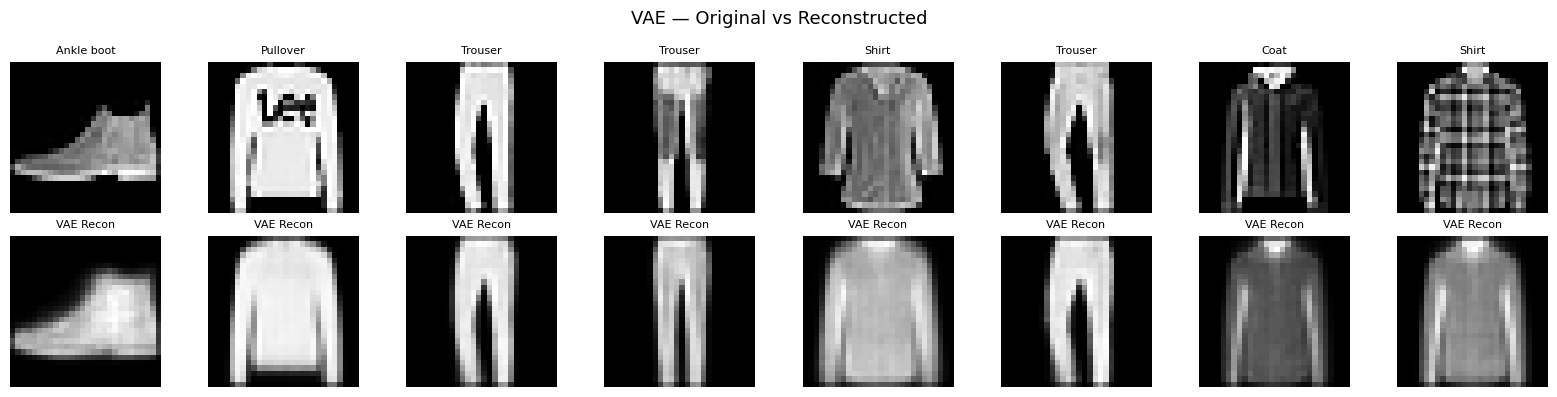

--- VAE Reconstruction Quality ---
  Mean SSIM : 0.5990

Note: VAE reconstructions are slightly blurrier than standard AE.
This is expected — VAE samples from a distribution rather than
mapping to a fixed point. The trade-off is a smooth, continuous
latent space that enables generation and interpolation.


In [14]:
# Get test batch
test_images_sample, test_labels_sample = next(iter(test_loader))
test_images_sample = test_images_sample.to(device)

vae_model.eval()
with torch.no_grad():
    reconstructed, mu, log_var = vae_model(test_images_sample)

originals_np     = test_images_sample.cpu().numpy()
reconstructed_np = reconstructed.cpu().numpy()

# ── Plot original vs VAE reconstructed ────────────────────────────────────
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))

for i in range(n):
    axes[0][i].imshow(originals_np[i].squeeze(), cmap='gray')
    axes[0][i].set_title(CLASS_NAMES[test_labels_sample[i].item()],
                          fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(reconstructed_np[i].squeeze(), cmap='gray')
    axes[1][i].set_title('VAE Recon', fontsize=8)
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Original',      fontsize=11)
axes[1][0].set_ylabel('VAE Recon',     fontsize=11)

plt.suptitle('VAE — Original vs Reconstructed', fontsize=13)
plt.tight_layout()
plt.show()

# ── SSIM for VAE ──────────────────────────────────────────────────────────
ssim_vae = []
for i in range(len(originals_np)):
    score = ssim(originals_np[i].squeeze(),
                 reconstructed_np[i].squeeze(),
                 data_range=1.0)
    ssim_vae.append(score)

print(f'--- VAE Reconstruction Quality ---')
print(f'  Mean SSIM : {np.mean(ssim_vae):.4f}')
print()
print('Note: VAE reconstructions are slightly blurrier than standard AE.')
print('This is expected — VAE samples from a distribution rather than')
print('mapping to a fixed point. The trade-off is a smooth, continuous')
print('latent space that enables generation and interpolation.')










# Evaluate the Variational Autoencoder through reconstruction visualization and perceptual similarity analysis

# - Generate reconstructed images from unseen test samples using the trained VAE.
# - Compare original and reconstructed Fashion-MNIST images qualitatively.
# - Assess reconstruction quality quantitatively using the Structural Similarity Index (SSIM) and summarize the VAE reconstruction characteristics.



# Visualize VAE reconstructions and measure reconstruction quality using the Structural Similarity Index (SSIM)

# - Retrieve a mini-batch of test images and their corresponding labels from the test `DataLoader`, then move the images to the selected computation device (`CPU` or `GPU`).
# - Switch the Variational Autoencoder to evaluation mode using `model.eval()` and disable gradient computation with `torch.no_grad()` because only inference is required.
# - Pass the test images through the VAE to obtain:
#   - The reconstructed images produced by the decoder.
#   - The latent means (`μ`).
#   - The latent log variances (`log_var`).
#   Although `μ` and `log_var` are returned, only the reconstructed images are used for visualization in this step.
# - Move both the original and reconstructed images back to the CPU and convert them into NumPy arrays so they can be displayed using Matplotlib.
# - Create a figure with two rows and eight columns to compare the original Fashion-MNIST images with their VAE reconstructions.
#   - The first row displays the original images labeled with their corresponding clothing categories.
#   - The second row displays the reconstructed images generated from the sampled latent vectors.
#   Example:

#       Original Image      →      VAE Reconstruction

#       Trouser                     Reconstructed Trouser

#   This side-by-side comparison illustrates how accurately the VAE reproduces the overall structure of each clothing item.
# - Compute the Structural Similarity Index (SSIM) for every image pair by comparing each original image with its reconstructed counterpart.
#   Example:
#     SSIM = 1.00  → Perfect structural similarity.
#     SSIM ≈ 0.90  → Very similar images.
#     SSIM ≈ 0.70  → Noticeable reconstruction differences.
#   Unlike pixel-wise losses, SSIM evaluates similarity based on luminance, contrast, and structural information, making it a better indicator of perceived image quality.
# - Calculate the mean SSIM across the entire batch to summarize the average reconstruction quality achieved by the VAE.
# - Print the average SSIM value along with an explanation that VAE reconstructions are typically slightly blurrier than those produced by a standard autoencoder.
#   This occurs because the VAE reconstructs images from randomly sampled latent vectors drawn from a learned probability distribution rather than fixed deterministic encodings.
# - Highlight the fundamental trade-off of Variational Autoencoders:
#   - Standard Autoencoder:
#       Sharper reconstructions but an irregular latent space.
#   - Variational Autoencoder:
#       Slightly blurrier reconstructions but a smooth, continuous latent space that supports meaningful interpolation, sampling, and generation of new images.

Latent space shape : (10000, 2)
Each point = one test image encoded to 2D


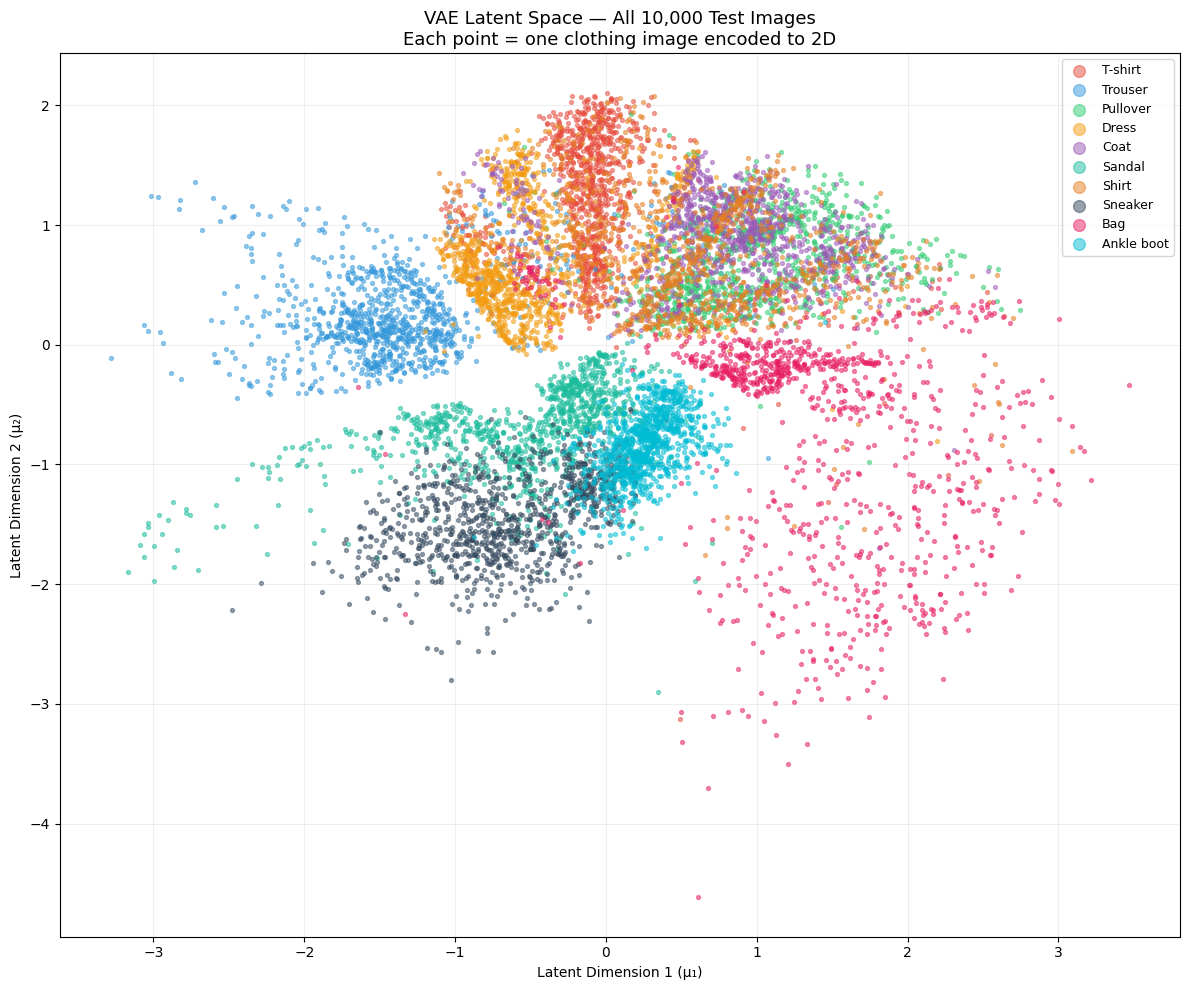


Well-trained VAE: same clothing types cluster together.
Neighboring clusters = visually similar items (e.g. Shirt ↔ T-shirt).
Smooth transitions between clusters = continuous latent space.


In [15]:
# ── PART 4: Latent Space Visualization ────────────────────────────────────
#
# Since latent_dim=2, every image maps to a single (x,y) point
# We can plot ALL test images in this 2D space, colored by class
# If the VAE learned well, same clothing types cluster together
# This is the most powerful visualization in generative modeling

vae_model.eval()

all_mu     = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _  = vae_model.encode(images)   # get mean of distribution
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)  # (10000, 2)
all_labels = np.concatenate(all_labels, axis=0)  # (10000,)

print(f'Latent space shape : {all_mu.shape}')
print(f'Each point = one test image encoded to 2D')

# ── Scatter plot ───────────────────────────────────────────────────────────
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6',
          '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4']

plt.figure(figsize=(12, 10))
for cls_idx in range(10):
    mask = all_labels == cls_idx
    plt.scatter(
        all_mu[mask, 0],
        all_mu[mask, 1],
        c      = colors[cls_idx],
        label  = CLASS_NAMES[cls_idx],
        alpha  = 0.5,
        s      = 8
    )

plt.colorbar
plt.title('VAE Latent Space — All 10,000 Test Images\n'
          'Each point = one clothing image encoded to 2D',
          fontsize=13)
plt.xlabel('Latent Dimension 1 (μ₁)')
plt.ylabel('Latent Dimension 2 (μ₂)')
plt.legend(markerscale=3, fontsize=9, loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('\nWell-trained VAE: same clothing types cluster together.')
print('Neighboring clusters = visually similar items (e.g. Shirt ↔ T-shirt).')
print('Smooth transitions between clusters = continuous latent space.')





# Visualize the learned VAE latent space using two-dimensional embeddings

# - Encode the entire Fashion-MNIST test set into the VAE's latent space.
# - Project each image as a point in a two-dimensional representation using the latent means.
# - Visualize class-wise clustering to assess the structure and continuity of the learned latent space.




# Encode all test images into the VAE latent space and visualize class distributions as a two-dimensional embedding

# - Switch the Variational Autoencoder to evaluation mode using `model.eval()` and disable gradient computation with `torch.no_grad()` because only latent representations are required.
# - Create two empty lists:
#   - `all_mu` to store the latent mean vectors (μ) for every test image.
#   - `all_labels` to store the corresponding Fashion-MNIST class labels.
# - Iterate through the entire test dataset one mini-batch at a time.
# - Pass each batch through the encoder using `vae_model.encode(images)` to obtain the latent mean (`μ`) and log variance (`log_var`).
#   Only the latent mean is retained because it provides the deterministic center of each learned latent distribution.
#   Example:
#     Input Image
#          │
#          ▼
#       Encoder
#          │
#      ┌───┴────┐
#      ▼        ▼
#       μ    log_var

#     Store only μ for visualization.
# - Move the latent vectors and labels to the CPU, convert them to NumPy arrays, and append them to their respective lists.
# - Combine all mini-batches into two complete arrays using `np.concatenate()`.
#   Example:
#     all_mu.shape     → (10000, 2)
#     all_labels.shape → (10000,)
#   Every one of the 10,000 test images is now represented as a single point in a two-dimensional latent space.
# - Create a scatter plot in which each point corresponds to one encoded image.
#   - The x-axis represents the first latent dimension (μ₁).
#   - The y-axis represents the second latent dimension (μ₂).
# - Separate images by their class labels and assign a unique color to each clothing category.
#   Example:
#     Blue points   → T-shirts
#     Green points  → Dresses
#     Purple points → Bags
#     ...
#   This allows the spatial distribution of different clothing types to be observed easily.
# - Display a legend, axis labels, title, and grid to improve readability and interpretation of the latent space visualization.
# - Interpret the resulting embedding:
#   - Images belonging to the same clothing category should naturally cluster together if the VAE has learned meaningful feature representations.
#   - Nearby clusters often correspond to visually similar classes.
#     Example:
#       Shirt ↔ T-shirt
#       Sneaker ↔ Ankle Boot
#       Coat ↔ Pullover
#   because these items share similar visual characteristics.
# - Highlight that the smooth arrangement of clusters demonstrates one of the primary advantages of Variational Autoencoders: a continuous and well-organized latent space where nearby points represent visually similar images, enabling meaningful interpolation, sampling, and generation of new data.

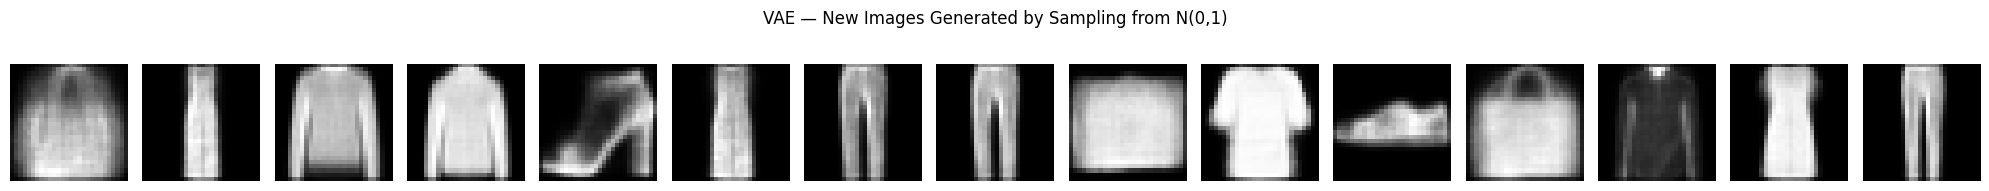

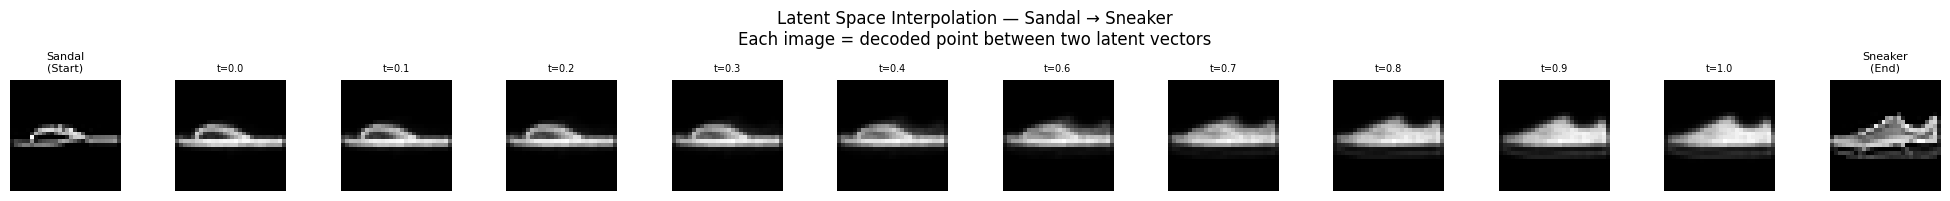

Smooth morphing confirms the VAE learned a continuous latent space.
Standard AE interpolation produces incoherent images — not clothing.
VAE interpolation produces valid clothing at every intermediate point.


In [16]:
# ── Generate new images by sampling from latent space ─────────────────────
# Standard AE cannot do this — its latent space has gaps
# VAE's KL loss forces a smooth N(0,1) distribution
# so ANY point sampled from N(0,1) decodes to a valid image

vae_model.eval()

# Sample random points from N(0,1)
num_samples = 15
z_random    = torch.randn(num_samples, 2).to(device)

with torch.no_grad():
    generated = vae_model.decode(z_random)

generated_np = generated.cpu().numpy()

fig, axes = plt.subplots(1, num_samples, figsize=(20, 2))
for i in range(num_samples):
    axes[i].imshow(generated_np[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.suptitle('VAE — New Images Generated by Sampling from N(0,1)',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Latent Space Interpolation ─────────────────────────────────────────────
# Pick two real test images from DIFFERENT classes
# Encode both to get their latent vectors
# Linearly interpolate between them
# Decode each interpolated point → smooth morphing between clothing types

# Find one Sandal and one Sneaker in test set
img_a, img_b = None, None
for img, lbl in test_dataset:
    if lbl == 5 and img_a is None:    # Sandal
        img_a = img
    if lbl == 7 and img_b is None:    # Sneaker
        img_b = img
    if img_a is not None and img_b is not None:
        break

img_a_t = img_a.unsqueeze(0).to(device)
img_b_t = img_b.unsqueeze(0).to(device)

with torch.no_grad():
    mu_a, _ = vae_model.encode(img_a_t)
    mu_b, _ = vae_model.encode(img_b_t)

# Interpolate: z = (1-t)*mu_a + t*mu_b  for t in [0,1]
steps        = 10
interpolated = []

for t in np.linspace(0, 1, steps):
    z_interp = (1 - t) * mu_a + t * mu_b
    with torch.no_grad():
        decoded = vae_model.decode(z_interp)
    interpolated.append(decoded.cpu().numpy())

# ── Plot interpolation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, steps + 2, figsize=(20, 2))

# Show start image
axes[0].imshow(img_a.squeeze(), cmap='gray')
axes[0].set_title('Sandal\n(Start)', fontsize=8)
axes[0].axis('off')

# Show interpolated images
for i, img in enumerate(interpolated):
    axes[i+1].imshow(img[0].squeeze(), cmap='gray')
    axes[i+1].set_title(f't={i/(steps-1):.1f}', fontsize=7)
    axes[i+1].axis('off')

# Show end image
axes[-1].imshow(img_b.squeeze(), cmap='gray')
axes[-1].set_title('Sneaker\n(End)', fontsize=8)
axes[-1].axis('off')

plt.suptitle('Latent Space Interpolation — Sandal → Sneaker\n'
             'Each image = decoded point between two latent vectors',
             fontsize=12)
plt.tight_layout()
plt.show()

print('Smooth morphing confirms the VAE learned a continuous latent space.')
print('Standard AE interpolation produces incoherent images — not clothing.')
print('VAE interpolation produces valid clothing at every intermediate point.')













# Demonstrate the generative capabilities of the Variational Autoencoder through latent space sampling and interpolation

# - Generate new Fashion-MNIST images by sampling random latent vectors from the learned latent distribution.
# - Visualize smooth transitions between two clothing categories using latent space interpolation.
# - Validate that the VAE has learned a continuous and meaningful latent representation suitable for image generation.





# Generate new images from the VAE latent space and demonstrate continuous interpolation between learned image representations

# - Switch the Variational Autoencoder to evaluation mode (`model.eval()`) so it performs inference without updating its parameters.
# - Generate 15 random latent vectors by sampling from a standard normal distribution using `torch.randn(num_samples, 2)`.
#   Example:
#     z₁ = [ 0.42, -1.18]
#     z₂ = [-0.73,  0.65]
#     ...
#   Since the VAE is trained to organize its latent space around the distribution `N(0,1)`, these randomly sampled vectors represent valid locations that can be decoded into realistic clothing images.
# - Pass each sampled latent vector directly through the decoder to generate completely new Fashion-MNIST images that were never present in the training dataset.
#   Example:

#       Random z
#          │
#          ▼
#       Decoder
#          │
#          ▼
#     Generated Clothing Image
# - Display all generated images in a single row, illustrating the VAE's ability to synthesize new samples rather than simply reconstruct existing inputs. This generative capability is possible because the KL divergence regularizes the latent space into a smooth continuous distribution.
# - Demonstrate latent space interpolation by selecting two real test images from different classes:
#   - Sandal (Class 5)
#   - Sneaker (Class 7)
# - Encode both images to obtain their latent mean vectors (`μₐ` and `μᵦ`), which serve as their locations within the learned latent space.
#   Example:
#     Sandal  → μₐ = (-1.8, 0.9)
#     Sneaker → μᵦ = ( 2.1,-0.6)
# - Create intermediate latent vectors using linear interpolation:
#     z = (1 − t) × μₐ + t × μᵦ
#   where `t` varies smoothly from `0` to `1`.
#   Example:
#     t = 0.0 → 100% Sandal
#     t = 0.5 → Equal mixture
#     t = 1.0 → 100% Sneaker
# - Decode each interpolated latent vector into an image, producing a gradual visual transformation between the two clothing categories.
#   Example:

#     Sandal
#        │
#        ▼
#     Sandal-like Shoe
#        ▼
#     Mixed Footwear
#        ▼
#     Sneaker-like Shoe
#        ▼
#     Sneaker
# - Display the interpolation sequence alongside the original start and end images, allowing the progression between the two latent representations to be observed visually.
# - Print concluding observations explaining that smooth transitions between valid images indicate the VAE has learned a continuous latent space. Unlike a standard autoencoder, whose latent space often contains disconnected regions that produce unrealistic outputs, the VAE's KL divergence regularization ensures that nearly any point sampled from the latent distribution decodes into a meaningful clothing image, enabling both image generation and smooth interpolation.

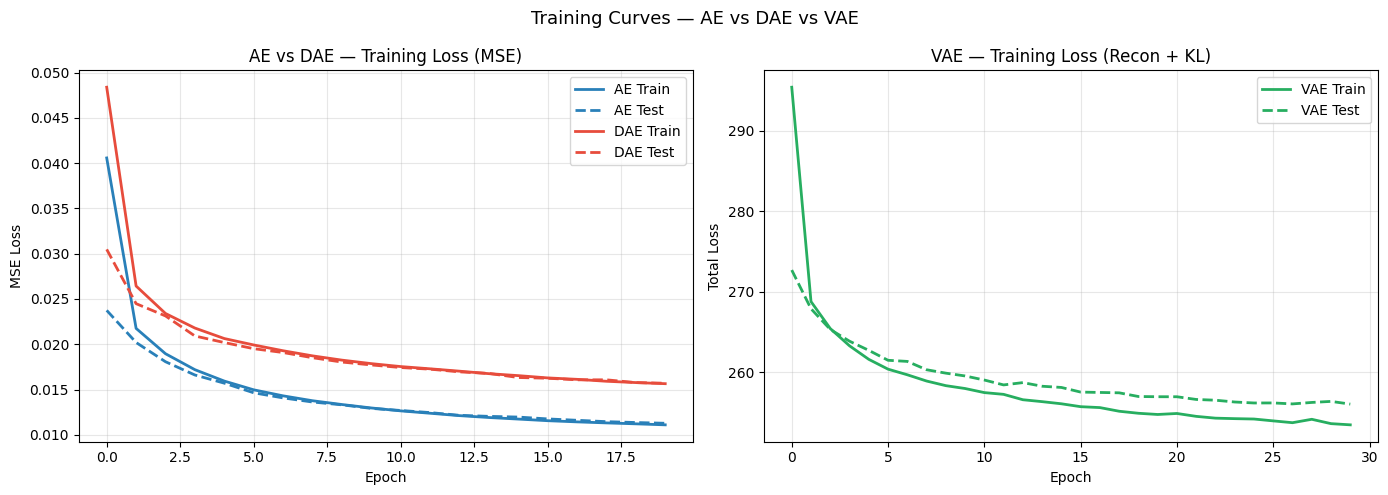

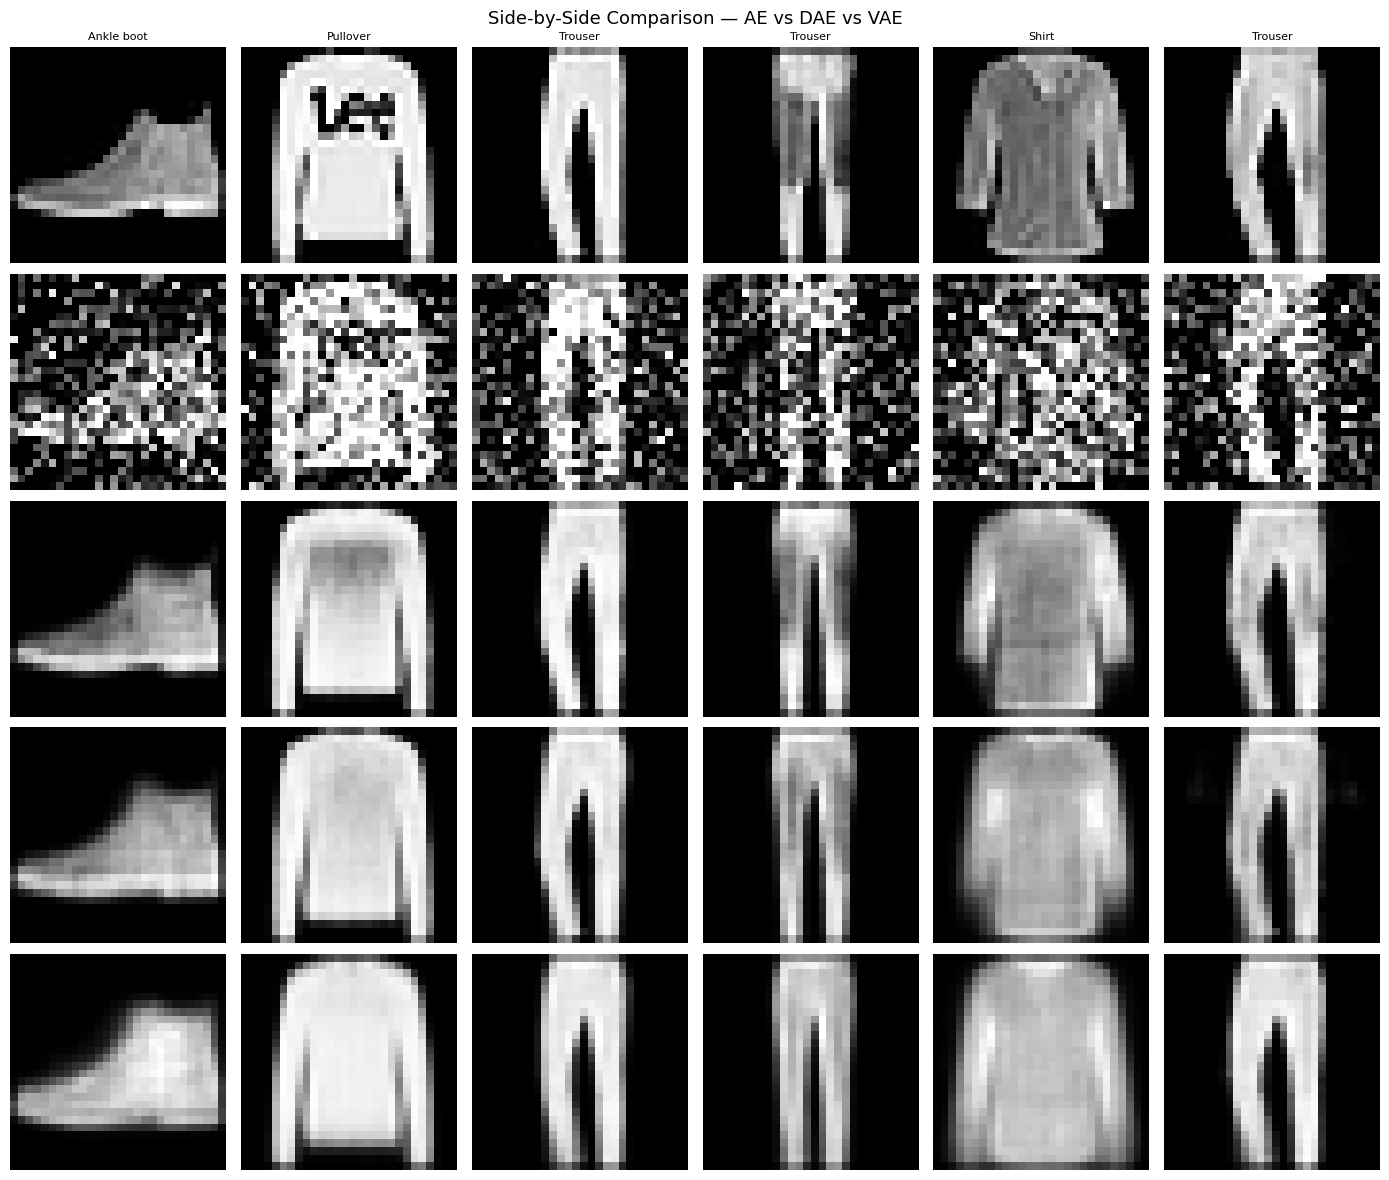

In [17]:
# ── Final Comparison: AE vs DAE vs VAE ────────────────────────────────────

# ── Training Loss Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ae_train_losses,  color='#2980b9', linewidth=2,
             label='AE Train')
axes[0].plot(ae_test_losses,   color='#2980b9', linewidth=2,
             linestyle='--', label='AE Test')
axes[0].plot(dae_train_losses, color='#e74c3c', linewidth=2,
             label='DAE Train')
axes[0].plot(dae_test_losses,  color='#e74c3c', linewidth=2,
             linestyle='--', label='DAE Test')
axes[0].set_title('AE vs DAE — Training Loss (MSE)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(vae_train_losses, color='#27ae60', linewidth=2,
             label='VAE Train')
axes[1].plot(vae_test_losses,  color='#27ae60', linewidth=2,
             linestyle='--', label='VAE Test')
axes[1].set_title('VAE — Training Loss (Recon + KL)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Total Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — AE vs DAE vs VAE', fontsize=13)
plt.tight_layout()
plt.show()

# ── Side by side reconstruction comparison ────────────────────────────────
test_images_sample, test_labels_sample = next(iter(test_loader))
test_images_sample = test_images_sample.to(device)
noisy_sample       = add_noise(test_images_sample, noise_factor=0.4)

ae_model.eval()
dae_model.eval()
vae_model.eval()

with torch.no_grad():
    ae_recon,  _      = ae_model(test_images_sample)
    dae_recon, _      = dae_model(noisy_sample)
    vae_recon, mu, lv = vae_model(test_images_sample)

originals_np  = test_images_sample.cpu().numpy()
noisy_np      = noisy_sample.cpu().numpy()
ae_recon_np   = ae_recon.cpu().numpy()
dae_recon_np  = dae_recon.cpu().numpy()
vae_recon_np  = vae_recon.cpu().numpy()

n   = 6
fig, axes = plt.subplots(5, n, figsize=(14, 12))
row_labels = ['Original', 'Noisy Input', 'AE Recon',
              'DAE Denoised', 'VAE Recon']

for i in range(n):
    axes[0][i].imshow(originals_np[i].squeeze(),  cmap='gray')
    axes[1][i].imshow(noisy_np[i].squeeze(),      cmap='gray')
    axes[2][i].imshow(ae_recon_np[i].squeeze(),   cmap='gray')
    axes[3][i].imshow(dae_recon_np[i].squeeze(),  cmap='gray')
    axes[4][i].imshow(vae_recon_np[i].squeeze(),  cmap='gray')

    axes[0][i].set_title(
        CLASS_NAMES[test_labels_sample[i].item()], fontsize=8)

    for row in range(5):
        axes[row][i].axis('off')

for row, label in enumerate(row_labels):
    axes[row][0].set_ylabel(label, fontsize=10)

plt.suptitle('Side-by-Side Comparison — AE vs DAE vs VAE', fontsize=13)
plt.tight_layout()
plt.show()




























# Implement a comparative evaluation pipeline for Standard AE, Denoising AE, and VAE

# - Visualize and compare the training behavior of all autoencoder variants.
# - Generate side-by-side reconstruction outputs from each trained model using a common set of test samples.
# - Provide a unified qualitative and quantitative comparison of reconstruction capabilities across the three architectures.





# Compare the learning performance and reconstruction quality of Standard Autoencoder, Denoising Autoencoder, and Variational Autoencoder

# - Plot the recorded training and testing loss histories of the Standard Autoencoder (AE) and Denoising Autoencoder (DAE) on a shared graph using Mean Squared Error (MSE) loss.
#   This allows their convergence rates and reconstruction performance to be compared directly over multiple training epochs.
# - Plot the Variational Autoencoder (VAE) training and testing losses separately because its objective function differs from the other models.
#   Unlike AE and DAE, the VAE optimizes:
#     Total Loss = Reconstruction Loss + KL Divergence
#   making its loss values not directly comparable with MSE-based autoencoders.
# - Display both graphs together to summarize how each architecture learns throughout training and whether the models generalize consistently to unseen test data.
# - Retrieve a fresh batch of Fashion-MNIST test images and create noisy versions using the previously defined Gaussian noise function.
#   These noisy images serve as inputs specifically for evaluating the Denoising Autoencoder.
# - Switch all three trained models (`AE`, `DAE`, and `VAE`) into evaluation mode to perform inference without updating network parameters.
# - Generate reconstructions from each model:
#   - Standard Autoencoder reconstructs the original clean images.
#   - Denoising Autoencoder reconstructs clean images from noisy inputs.
#   - Variational Autoencoder reconstructs images by encoding them into a probabilistic latent space and decoding sampled latent vectors.
# - Move the original images, noisy inputs, and all reconstructed outputs back to the CPU and convert them into NumPy arrays for visualization.
# - Create a five-row comparison figure where each column corresponds to the same test sample.
#   The rows represent:
#   1. Original image.
#   2. Noisy input image.
#   3. Standard Autoencoder reconstruction.
#   4. Denoising Autoencoder reconstruction.
#   5. Variational Autoencoder reconstruction.
#   Example:

#       Original
#          │
#       Noisy Input
#          │
#       AE Reconstruction
#          │
#       DAE Reconstruction
#          │
#       VAE Reconstruction

#   This layout allows the strengths and weaknesses of each architecture to be compared on identical inputs.
# - Label the first row with the corresponding Fashion-MNIST class names and annotate each row to clearly distinguish the outputs produced by the three autoencoder variants.
# - Present the final visualization as a comprehensive comparison of reconstruction quality:
#   - Standard AE demonstrates efficient image compression and reconstruction.
#   - DAE highlights its ability to remove Gaussian noise while preserving image structure.
#   - VAE produces slightly smoother or blurrier reconstructions in exchange for learning a continuous latent space capable of image generation and interpolation.
#   Together, these plots summarize the practical differences between deterministic, denoising, and probabilistic autoencoder architectures.

In [19]:
# Compute SSIM for all three models on same batch
ssim_ae  = []
ssim_dae = []
ssim_vae = []

for i in range(len(originals_np)):
    ssim_ae.append(ssim(
        originals_np[i].squeeze(),
        ae_recon_np[i].squeeze(),
        data_range=1.0
    ))
    ssim_dae.append(ssim(
        originals_np[i].squeeze(),
        dae_recon_np[i].squeeze(),
        data_range=1.0
    ))
    ssim_vae.append(ssim(
        originals_np[i].squeeze(),
        vae_recon_np[i].squeeze(),
        data_range=1.0
    ))

print('=' * 60)
print('        EXPERIMENT 5 — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset         : Fashion MNIST (60,000 train / 10,000 test)')
print(f'Framework       : PyTorch')
print()
print(f'--- Models Built ---')
print(f'{"Model":<28} {"Latent Dim":>12} {"Params":>10}')
print('-' * 52)
print(f'{"Standard AE":<28} {"32":>12}'
      f'{sum(p.numel() for p in ae_model.parameters()):>10,}')
print(f'{"Denoising AE":<28} {"32":>12}'
      f'{sum(p.numel() for p in dae_model.parameters()):>10,}')
print(f'{"VAE":<28} {"2":>12}'
      f'{sum(p.numel() for p in vae_model.parameters()):>10,}')
print()
print(f'--- Reconstruction Quality (SSIM) ---')
print(f'  Standard AE  : {np.mean(ssim_ae):.4f}')
print(f'  Denoising AE : {np.mean(ssim_dae):.4f}  '
      f'(from noisy input, noise_factor=0.4)')
print(f'  VAE          : {np.mean(ssim_vae):.4f}  '
      f'(slightly blurry — expected)')
print()
print(f'--- Unique Capabilities ---')
print(f'  Standard AE  : compression, reconstruction')
print(f'  Denoising AE : compression + noise removal')
print(f'  VAE          : compression + generation + interpolation')
print()
print(f'--- Key Concepts Demonstrated ---')
print(f'  ✓ Encoder-Decoder architecture')
print(f'  ✓ MSE reconstruction loss')
print(f'  ✓ Gaussian noise injection for denoising')
print(f'  ✓ Reparameterization trick (z = μ + σ×ε)')
print(f'  ✓ KL divergence — smooth latent space')
print(f'  ✓ Latent space visualization (2D scatter)')
print(f'  ✓ New image generation from N(0,1) sampling')
print(f'  ✓ Latent space interpolation between classes')
print(f'  ✓ SSIM — quantitative reconstruction metric')
print('=' * 60)

        EXPERIMENT 5 — FINAL SUMMARY
Dataset         : Fashion MNIST (60,000 train / 10,000 test)
Framework       : PyTorch

--- Models Built ---
Model                          Latent Dim     Params
----------------------------------------------------
Standard AE                            32   476,720
Denoising AE                           32   476,720
VAE                                     2   790,388

--- Reconstruction Quality (SSIM) ---
  Standard AE  : 0.7407
  Denoising AE : 0.6751  (from noisy input, noise_factor=0.4)
  VAE          : 0.6005  (slightly blurry — expected)

--- Unique Capabilities ---
  Standard AE  : compression, reconstruction
  Denoising AE : compression + noise removal
  VAE          : compression + generation + interpolation

--- Key Concepts Demonstrated ---
  ✓ Encoder-Decoder architecture
  ✓ MSE reconstruction loss
  ✓ Gaussian noise injection for denoising
  ✓ Reparameterization trick (z = μ + σ×ε)
  ✓ KL divergence — smooth latent space
  ✓ Latent spa